<a href="https://colab.research.google.com/github/Myllertg/customer-segmentation-kmeans/blob/main/Customer-Segmentation-Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Entendimento do Problema

## 1.1 Objetivo do Negócio

O objetivo deste projeto é **segmentar clientes de uma instituição financeira em grupos com características e comportamentos semelhantes**, utilizando dados relacionados ao seu perfil de crédito e relacionamento com o banco.

Essa segmentação poderá auxiliar na identificação de diferentes perfis de clientes e na criação de estratégias comerciais e de relacionamento mais direcionadas.

## 1.2 Tipo de Problema

O projeto utiliza **Machine Learning não supervisionado**, caracterizado como um problema de **Clustering**.

Será utilizado o algoritmo **K-Means**, que busca agrupar clientes com características semelhantes em diferentes clusters, sem a necessidade de uma variável-alvo previamente definida.

## 1.3 Métrica de Sucesso

A qualidade dos clusters será avaliada principalmente por meio do **Silhouette Score** e da **Inertia (WCSS)**. O **Método do Cotovelo (Elbow Method)** também será utilizado para auxiliar na definição do número adequado de clusters.

Além da avaliação estatística, os clusters deverão apresentar **perfis interpretáveis e relevância para o negócio**, permitindo identificar diferenças entre os segmentos de clientes.


In [19]:

#COLETA DE DADOS
#INSTALAÇÃO DA API DO KAGGLE
!pip install -q kaggle

#CONFIGURAÇÃO
from pathlib import Path
import pandas as pd
import zipfile
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline


DATA_DIR = Path("./data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATASET = "aryashah2k/credit-card-customer-data"

#DOWNLOAD DO DATASET
!kaggle datasets download -d {DATASET} -p {DATA_DIR}

#IDENTIFICAÇÃO DO ARQUIVO ZIP
zip_files = list(DATA_DIR.glob("*.zip"))

if not zip_files:
    raise FileNotFoundError(
        "Nenhum arquivo ZIP foi encontrado após o download."
    )

ZIP_PATH = zip_files[0]

print("=" * 70)
print("DOWNLOAD CONCLUÍDO")
print("=" * 70)
print(f"Dataset: {DATASET}")
print(f"Arquivo: {ZIP_PATH.name}")


#EXTRAÇÃO DOS ARQUIVOS
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

print("\nArquivos extraídos:")

for file in DATA_DIR.iterdir():
    if file.is_file():
        print(f" - {file.name}")


#IDENTIFICAÇÃO DO CSV
csv_files = list(DATA_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "Nenhum arquivo CSV foi encontrado após a extração."
    )

CSV_PATH = csv_files[0]


#CARREGAMENTO DOS DADOS
df = pd.read_csv(CSV_PATH)


Dataset URL: https://www.kaggle.com/datasets/aryashah2k/credit-card-customer-data
License(s): CC0-1.0
credit-card-customer-data.zip: Skipping, found more recently modified local copy (use --force to force download)
DOWNLOAD CONCLUÍDO
Dataset: aryashah2k/credit-card-customer-data
Arquivo: credit-card-customer-data.zip

Arquivos extraídos:
 - credit-card-customer-data.zip
 - Credit Card Customer Data.csv


1. VISÃO GERAL DA BASE
Registros..............: 660
Colunas................: 7
Memória utilizada......: 0.04 MB
Valores ausentes.......: 0
Registros duplicados...: 0

2. ESTRUTURA DOS DADOS


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4


,Tipo,Nulos,% Nulos,Valores Únicos
Sl_No,int64,0,0.00,660
Customer Key,int64,0,0.00,655
Avg_Credit_Limit,int64,0,0.00,110
Total_Credit_Cards,int64,0,0.00,10
Total_visits_bank,int64,0,0.00,6
Total_visits_online,int64,0,0.00,16
Total_calls_made,int64,0,0.00,11



3. ESTATÍSTICAS DESCRITIVAS


,count,mean,std,min,25%,50%,75%,max
Sl_No,660.00,330.50,190.67,1.00,165.75,330.50,495.25,660.00
Customer Key,660.00,"55,141.44","25,627.77","11,265.00","33,825.25","53,874.50","77,202.50","99,843.00"
Avg_Credit_Limit,660.00,"34,574.24","37,625.49","3,000.00","10,000.00","18,000.00","48,000.00","200,000.00"
Total_Credit_Cards,660.00,4.71,2.17,1.00,3.00,5.00,6.00,10.00
Total_visits_bank,660.00,2.40,1.63,0.00,1.00,2.00,4.00,5.00
Total_visits_online,660.00,2.61,2.94,0.00,1.00,2.00,4.00,15.00
Total_calls_made,660.00,3.58,2.87,0.00,1.00,3.00,5.00,10.00



4. VARIÁVEIS PARA CLUSTERING
Variáveis candidatas: 5
- Avg_Credit_Limit
- Total_Credit_Cards
- Total_visits_bank
- Total_visits_online
- Total_calls_made

5. ANÁLISE DE OUTLIERS


,Variável,Q1,Q3,Limite Inferior,Limite Superior,Outliers,% Outliers
0,Avg_Credit_Limit,"10,000.00","48,000.00","-47,000.00","105,000.00",39,5.91%
1,Total_Credit_Cards,3.00,6.00,-1.50,10.50,0,0.00%
2,Total_visits_bank,1.00,4.00,-3.50,8.50,0,0.00%
3,Total_visits_online,1.00,4.00,-3.50,8.50,37,5.61%
4,Total_calls_made,1.00,5.00,-5.00,11.00,0,0.00%



6. MATRIZ DE CORRELAÇÃO


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Avg_Credit_Limit,1.00,0.61,-0.10,0.55,-0.41
Total_Credit_Cards,0.61,1.00,0.32,0.17,-0.65
Total_visits_bank,-0.10,0.32,1.00,-0.55,-0.51
Total_visits_online,0.55,0.17,-0.55,1.00,0.13
Total_calls_made,-0.41,-0.65,-0.51,0.13,1.00


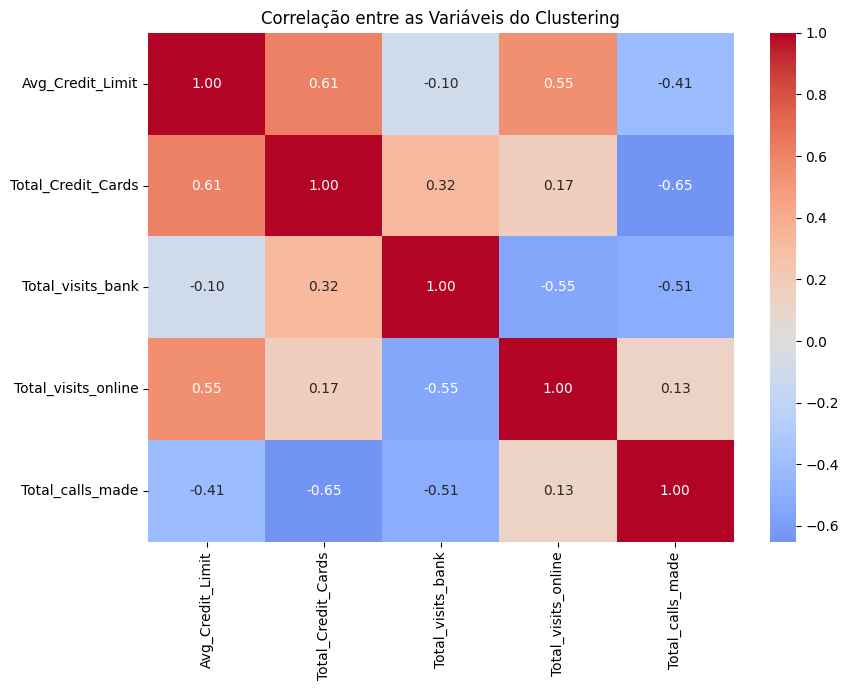


7. DISTRIBUIÇÃO DAS VARIÁVEIS


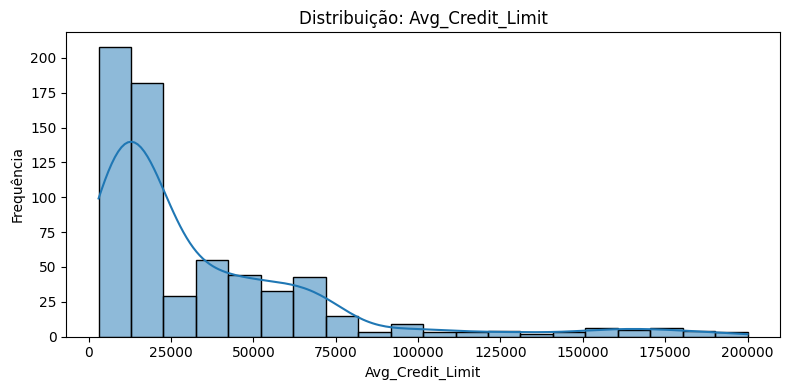

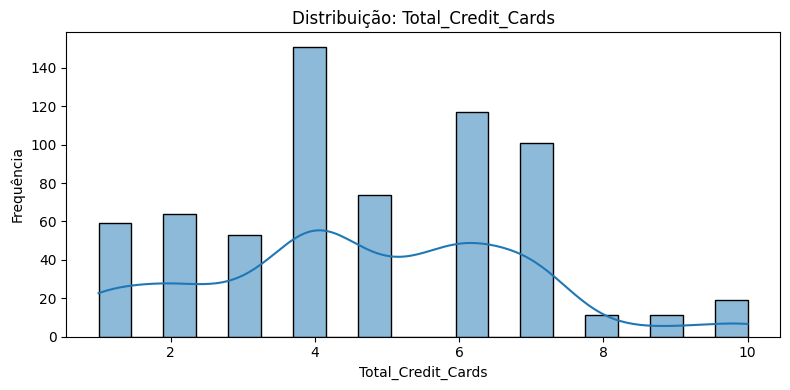

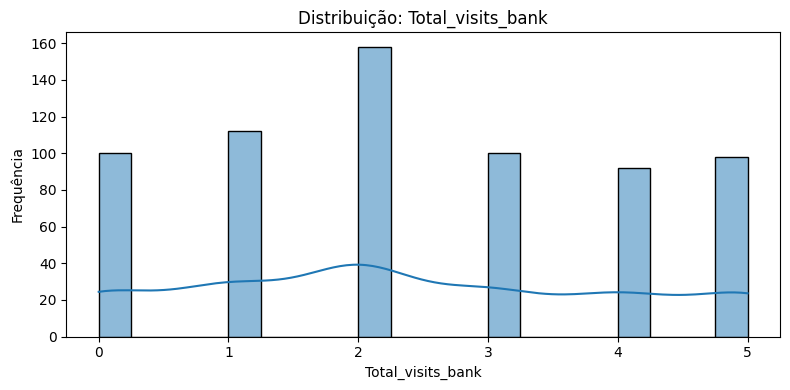

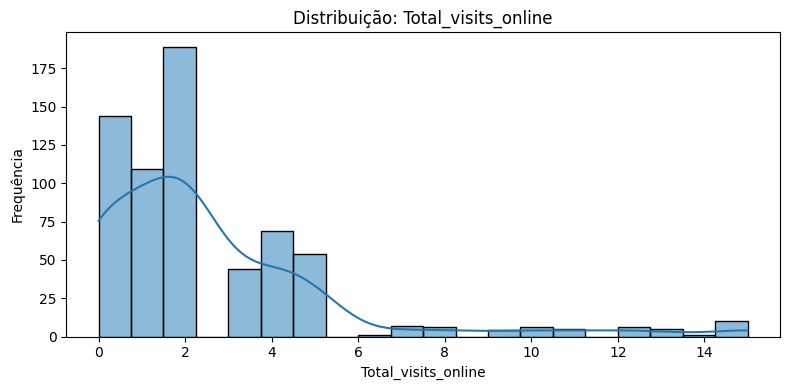

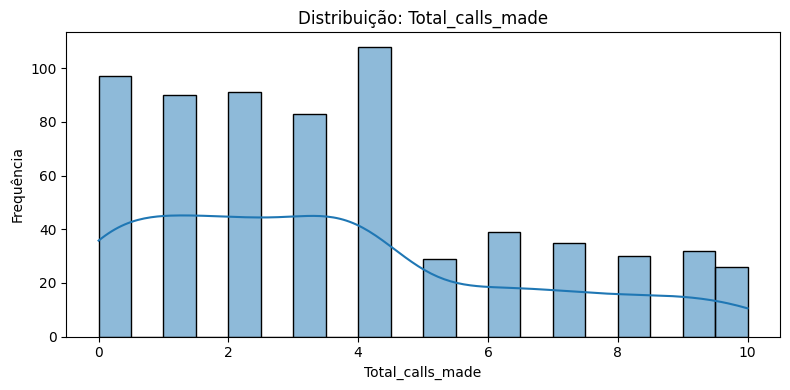


8. RELAÇÕES ENTRE VARIÁVEIS


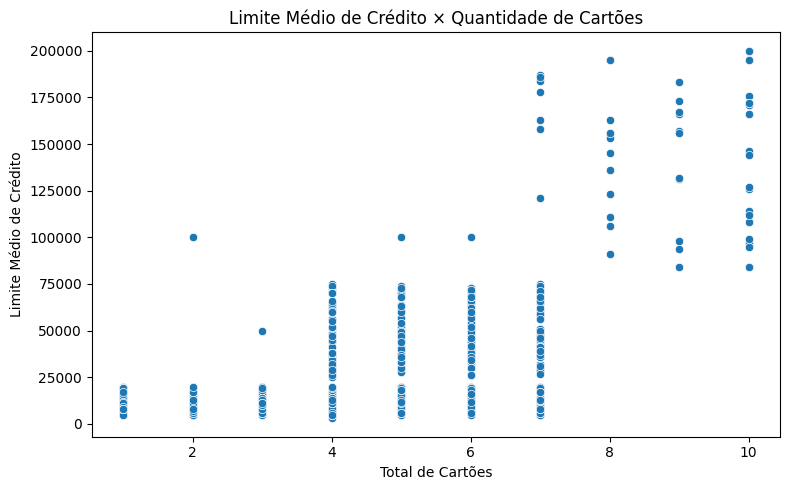

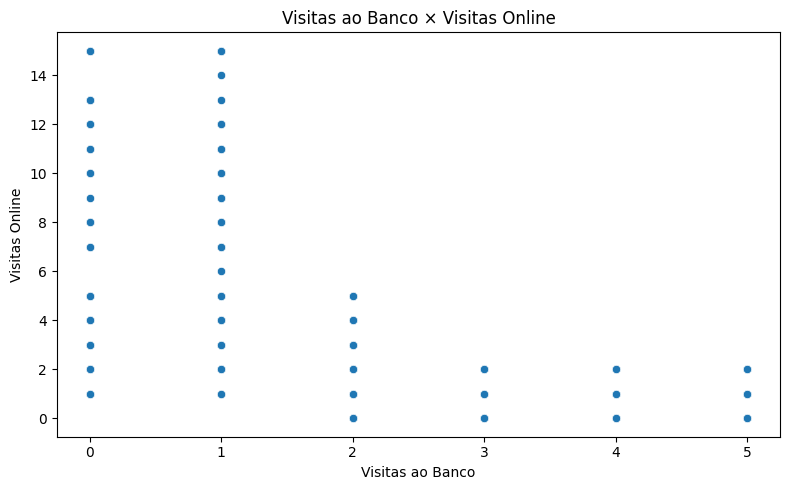

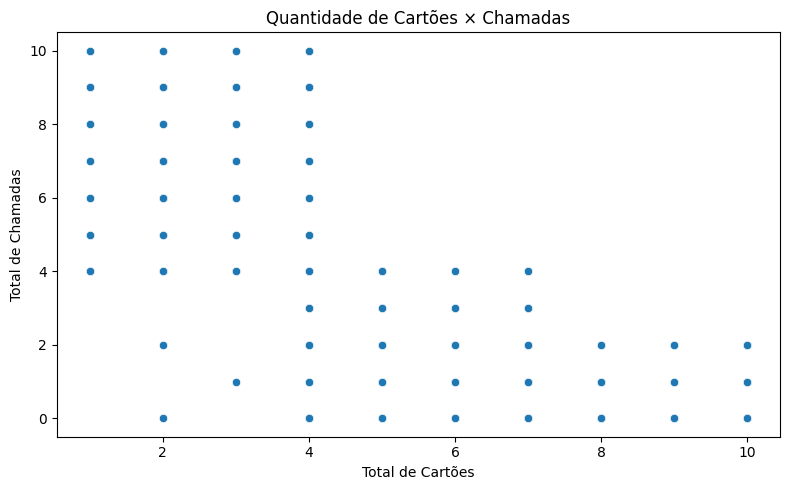


9. CLIENTES COM MAIOR LIMITE DE CRÉDITO


,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
630,33837,200000,10,0,13,0
631,14916,195000,8,0,15,0
650,78996,195000,10,1,12,2
632,97935,187000,7,1,7,0
646,58392,186000,7,0,8,1
639,90839,184000,7,1,15,2
647,79953,183000,9,0,9,2
624,97285,178000,7,0,11,0
622,53916,176000,10,1,15,2
637,88442,173000,9,1,11,0



10. CLIENTES COM MAIOR USO ONLINE


,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
640,99843,123000,8,1,15,2
658,80655,172000,10,1,15,0
653,51826,95000,10,0,15,1
620,32107,108000,10,0,15,1
622,53916,176000,10,1,15,2
628,75009,84000,9,1,15,0
639,90839,184000,7,1,15,2
644,18519,127000,10,1,15,1
645,48762,171000,10,0,15,0
631,14916,195000,8,0,15,0



11. CUSTOMER KEY REPETIDAS
Customer Keys repetidas: 5


,Quantidade
Customer Key,
96929,2
47437,2
50706,2
37252,2
97935,2



Registros correspondentes:


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
48,49,37252,6000,4,0,2,8
432,433,37252,59000,6,2,1,2
332,333,47437,17000,7,3,1,0
4,5,47437,100000,6,0,12,3
411,412,50706,44000,4,5,0,2
541,542,50706,60000,7,5,2,2
391,392,96929,13000,4,5,0,0
398,399,96929,67000,6,2,2,2
104,105,97935,17000,2,1,2,10
632,633,97935,187000,7,1,7,0


In [2]:
#ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

# CONFIGURAÇÕES
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

#VISÃO GERAL
print("=" * 80)
print("1. VISÃO GERAL DA BASE")
print("=" * 80)

duplicados = df.duplicated().sum()

print(f"Registros..............: {df.shape[0]:,}")
print(f"Colunas................: {df.shape[1]}")
print(f"Memória utilizada......: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Valores ausentes.......: {df.isna().sum().sum():,}")
print(f"Registros duplicados...: {duplicados:,}")


#ESTRUTURA DOS DADOS
print("\n" + "=" * 80)
print("2. ESTRUTURA DOS DADOS")
print("=" * 80)

display(df.head(3))

info_df = pd.DataFrame({
    "Tipo": df.dtypes,
    "Nulos": df.isna().sum(),
    "% Nulos": (df.isna().mean() * 100).round(2),
    "Valores Únicos": df.nunique()
})

display(info_df)


#ESTATÍSTICAS DESCRITIVAS
print("\n" + "=" * 80)
print("3. ESTATÍSTICAS DESCRITIVAS")
print("=" * 80)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

display(
    df[numeric_cols]
    .describe()
    .T
)


#DEFINIÇÃO DAS VARIÁVEIS PARA O CLUSTERING
print("\n" + "=" * 80)
print("4. VARIÁVEIS PARA CLUSTERING")
print("=" * 80)

#Identificadores que não representam características do cliente
identifiers = [
    "Sl_No",
    "Customer Key"
]

#Variáveis candidatas
candidate_cols = [
    col for col in numeric_cols
    if col not in identifiers
]

print(f"Variáveis candidatas: {len(candidate_cols)}")

for col in candidate_cols:
    print(f"- {col}")


#ANÁLISE DE OUTLIERS
print("\n" + "=" * 80)
print("5. ANÁLISE DE OUTLIERS")
print("=" * 80)

outliers = []

for col in candidate_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    n_outliers = (
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    ).sum()

    outliers.append({
        "Variável": col,
        "Q1": Q1,
        "Q3": Q3,
        "Limite Inferior": limite_inferior,
        "Limite Superior": limite_superior,
        "Outliers": n_outliers,
        "% Outliers": round(
            n_outliers / len(df) * 100,
            2
        )
    })

outliers_df = pd.DataFrame(outliers)

display(
    outliers_df.style.format({
        "Q1": "{:,.2f}",
        "Q3": "{:,.2f}",
        "Limite Inferior": "{:,.2f}",
        "Limite Superior": "{:,.2f}",
        "% Outliers": "{:.2f}%"
    })
)


#MATRIZ DE CORRELAÇÃO
print("\n" + "=" * 80)
print("6. MATRIZ DE CORRELAÇÃO")
print("=" * 80)

correlation = df[candidate_cols].corr()

display(
    correlation.round(2)
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlação entre as Variáveis do Clustering")
plt.tight_layout()
plt.show()

#DISTRIBUIÇÃO DAS VARIÁVEIS
print("\n" + "=" * 80)
print("7. DISTRIBUIÇÃO DAS VARIÁVEIS")
print("=" * 80)

for col in candidate_cols:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f"Distribuição: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")

    plt.tight_layout()
    plt.show()


#RELAÇÕES ENTRE AS PRINCIPAIS VARIÁVEIS
print("\n" + "=" * 80)
print("8. RELAÇÕES ENTRE VARIÁVEIS")
print("=" * 80)

# Limite de crédito x quantidade de cartões
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Total_Credit_Cards",
    y="Avg_Credit_Limit"
)

plt.title("Limite Médio de Crédito × Quantidade de Cartões")
plt.xlabel("Total de Cartões")
plt.ylabel("Limite Médio de Crédito")

plt.tight_layout()
plt.show()

#Visitas ao banco x visitas online
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Total_visits_bank",
    y="Total_visits_online"
)

plt.title("Visitas ao Banco × Visitas Online")
plt.xlabel("Visitas ao Banco")
plt.ylabel("Visitas Online")

plt.tight_layout()
plt.show()


#Cartões x chamadas
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Total_Credit_Cards",
    y="Total_calls_made"
)

plt.title("Quantidade de Cartões × Chamadas")
plt.xlabel("Total de Cartões")
plt.ylabel("Total de Chamadas")

plt.tight_layout()
plt.show()

#CLIENTES COM MAIOR LIMITE
print("\n" + "=" * 80)
print("9. CLIENTES COM MAIOR LIMITE DE CRÉDITO")
print("=" * 80)

display(
    df[
        [
            "Customer Key",
            "Avg_Credit_Limit",
            "Total_Credit_Cards",
            "Total_visits_bank",
            "Total_visits_online",
            "Total_calls_made"
        ]
    ]
    .sort_values(
        "Avg_Credit_Limit",
        ascending=False
    )
    .head(15)
)

#CLIENTES COM MAIOR USO ONLINE
print("\n" + "=" * 80)
print("10. CLIENTES COM MAIOR USO ONLINE")
print("=" * 80)

display(
    df[
        [
            "Customer Key",
            "Avg_Credit_Limit",
            "Total_Credit_Cards",
            "Total_visits_bank",
            "Total_visits_online",
            "Total_calls_made"
        ]
    ]
    .sort_values(
        "Total_visits_online",
        ascending=False
    )
    .head(15)
)

#CUSTOMER KEY REPETIDAS
print("\n" + "=" * 80)
print("11. CUSTOMER KEY REPETIDAS")
print("=" * 80)

customer_key_counts = df["Customer Key"].value_counts()

repeated_keys = customer_key_counts[
    customer_key_counts > 1
]

print(
    f"Customer Keys repetidas: {len(repeated_keys)}"
)

if len(repeated_keys) > 0:

    display(
        repeated_keys
        .rename("Quantidade")
        .to_frame()
    )

    print("\nRegistros correspondentes:")

    display(
        df[
            df["Customer Key"].isin(
                repeated_keys.index
            )
        ]
        .sort_values("Customer Key")
    )

else:

    print("Nenhuma Customer Key repetida.")


#Entendimento e Análise Exploratória dos Dados

Nesta etapa foi realizada uma análise exploratória da base com **660 registros e 7 variáveis**, com o objetivo de compreender a estrutura dos dados, identificar problemas de qualidade e avaliar quais variáveis poderiam representar o comportamento dos clientes para o K-Means.

A base apresentou **nenhum valor ausente e nenhum registro duplicado**, indicando boa qualidade estrutural.

As variáveis `Sl_No` e `Customer Key` foram identificadas como **identificadores** e, portanto, não serão utilizadas como características no agrupamento.

As cinco variáveis comportamentais selecionadas foram:

- `Avg_Credit_Limit`
- `Total_Credit_Cards`
- `Total_visits_bank`
- `Total_visits_online`
- `Total_calls_made`

##Escala e Outliers

A análise estatística mostrou diferenças importantes de escala entre as variáveis. O principal exemplo é `Avg_Credit_Limit`, que varia de **3.000 a 200.000**, enquanto as demais variáveis apresentam intervalos muito menores.

Também foram identificados possíveis outliers em:

- `Avg_Credit_Limit`: **39 registros (5,91%)**
- `Total_visits_online`: **37 registros (5,61%)**

Esses valores foram mantidos, pois podem representar comportamentos reais e relevantes para a identificação de segmentos específicos de clientes.

A diferença de escala deverá ser tratada posteriormente por meio de **padronização**, evitando que variáveis com valores numericamente maiores tenham maior influência no cálculo das distâncias do K-Means.

##Correlação entre as Variáveis

A análise de correlação revelou alguns relacionamentos relevantes:

- `Avg_Credit_Limit` × `Total_Credit_Cards`: **0,61**
- `Avg_Credit_Limit` × `Total_visits_online`: **0,55**
- `Total_Credit_Cards` × `Total_calls_made`: **-0,65**
- `Total_visits_bank` × `Total_calls_made`: **-0,51**

Essas relações indicam diferentes padrões de utilização dos produtos e canais de atendimento.

Por exemplo, clientes com maior limite de crédito tendem a possuir mais cartões e apresentar maior utilização do canal online. Por outro lado, a relação negativa entre quantidade de cartões e ligações pode indicar perfis com diferentes formas de relacionamento com a instituição.

##Análise Inicial do Comportamento dos Clientes

Também foram analisados os clientes com maior limite de crédito e maior utilização do canal online.

Essa análise inicial indicou que clientes com limites mais elevados frequentemente apresentam maior quantidade de cartões e maior utilização dos canais digitais.

Ao mesmo tempo, existem clientes com limites menores que apresentam maior utilização do atendimento por telefone.

Esses comportamentos reforçam a possibilidade de existência de **diferentes perfis de clientes** que podem ser identificados por meio do clustering.

##Customer Keys Repetidas

Foi identificada a existência de **5 Customer Keys repetidas**, totalizando **10 registros**.

Como o objetivo do projeto é realizar uma segmentação de clientes e cada registro deve representar uma unidade de análise, essas duplicidades foram investigadas.

A decisão foi tratar essas ocorrências na etapa de preparação dos dados, garantindo que cada cliente seja representado de forma única antes da aplicação do K-Means.

##Insight Principal

A análise exploratória mostrou que a base possui qualidade suficiente para aplicação do K-Means e apresenta **heterogeneidade no comportamento dos clientes**, principalmente em relação a:

- Limite de crédito
- Quantidade de cartões
- Utilização do banco físico
- Utilização do canal online
- Utilização do atendimento telefônico

Essa heterogeneidade é importante porque o objetivo do K-Means é justamente identificar grupos de clientes com características semelhantes e diferentes entre si.

##Conclusão

A EDA permitiu compreender as principais características da base e definiu quais variáveis serão utilizadas no modelo.

As principais decisões foram:

- `Sl_No` e `Customer Key` não serão utilizadas no modelo;
- As cinco variáveis comportamentais serão utilizadas no clustering;
- Os outliers serão mantidos;
- As Customer Keys repetidas serão tratadas;
- As variáveis precisarão ser padronizadas antes da aplicação do K-Means.


In [3]:
#LIMPEZA E PREPARAÇÃO DOS DADOS
#CÓPIA DA BASE ORIGINAL
df_clean = df.copy()



#INVESTIGAÇÃO DAS CUSTOMER KEYS REPETIDAS
print("\n" + "=" * 80)
print("1. CUSTOMER KEYS REPETIDAS")
print("=" * 80)

customer_key_counts = df_clean["Customer Key"].value_counts()

repeated_keys = customer_key_counts[
    customer_key_counts > 1
]

print(
    f"Customer Keys repetidas: {len(repeated_keys)}"
)

if len(repeated_keys) > 0:

    print("\nChaves repetidas:")

    display(
        repeated_keys
        .rename("Quantidade de Registros")
        .to_frame()
    )

    print("\nRegistros associados às chaves repetidas:")

    conflicting_records = (
        df_clean[
            df_clean["Customer Key"].isin(
                repeated_keys.index
            )
        ]
        .sort_values("Customer Key")
    )

    display(conflicting_records)



else:

    print(
        "\nNenhuma Customer Key repetida encontrada."
    )



#BASE DE MODELAGEM
df_model = df_clean.copy()

print("\n" + "=" * 80)
print("2. BASE DE MODELAGEM")
print("=" * 80)

print(f"Registros na base original: {len(df_clean):,}")
print(f"Registros removidos: {len(df_clean) - len(df_model):,}")
print(f"Registros para modelagem: {len(df_model):,}")

print(
    f"Customer Keys únicas: "
    f"{df_model['Customer Key'].nunique():,}"
)

print(
    f"Customer Keys repetidas mantidas: "
    f"{len(repeated_keys):,}"
)


#DEFINIÇÃO DAS FEATURES
print("\n" + "=" * 80)
print("3. VARIÁVEIS PARA O K-MEANS")
print("=" * 80)

features = [
    "Avg_Credit_Limit",
    "Total_Credit_Cards",
    "Total_visits_bank",
    "Total_visits_online",
    "Total_calls_made"
]

for feature in features:
    print(f"- {feature}")


#CRIAÇÃO DA MATRIZ DE MODELAGEM
X = df_model[features].copy()

print("\n" + "=" * 80)
print("4. MATRIZ DE MODELAGEM")
print("=" * 80)

print(f"Dimensões de X: {X.shape}")

display(X.head())


#VERIFICAÇÃO DOS TIPOS
print("\n" + "=" * 80)
print("5. TIPOS DAS FEATURES")
print("=" * 80)

display(
    X.dtypes.to_frame("Tipo")
)



#VERIFICAÇÃO DE VALORES INVÁLIDOS
print("\n" + "=" * 80)
print("6. VALORES INVÁLIDOS")
print("=" * 80)

invalid_values = {}

for col in features:

    invalid_values[col] = {
        "Valores negativos": (X[col] < 0).sum(),
        "Zeros": (X[col] == 0).sum(),
        "Valores infinitos": np.isinf(X[col]).sum()
    }

invalid_df = pd.DataFrame(invalid_values).T

display(invalid_df)


#VERIFICAÇÃO DOS LIMITES DAS VARIÁVEIS
print("\n" + "=" * 80)
print("7. VALIDAÇÃO DOS VALORES")
print("=" * 80)

validation = pd.DataFrame({
    "Mínimo": X.min(),
    "Máximo": X.max(),
    "Média": X.mean(),
    "Mediana": X.median(),
    "Desvio Padrão": X.std()
})

display(
    validation.style.format("{:,.2f}")
)


#VERIFICAÇÃO FINAL DOS OUTLIERS
print("\n" + "=" * 80)
print("8. OUTLIERS")
print("=" * 80)

outlier_summary = []

for col in features:

    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = (
        (X[col] < lower) |
        (X[col] > upper)
    ).sum()

    outlier_summary.append({
        "Variável": col,
        "Outliers": n_outliers,
        "%": n_outliers / len(X) * 100
    })

outlier_summary = pd.DataFrame(
    outlier_summary
)

display(
    outlier_summary.style.format({
        "%": "{:.2f}%"
    })
)

#COMPARAÇÃO DAS ESCALAS
print("\n" + "=" * 80)
print("9. ESCALAS DAS VARIÁVEIS")
print("=" * 80)

scale_comparison = pd.DataFrame({
    "Mínimo": X.min(),
    "Máximo": X.max(),
    "Amplitude": X.max() - X.min()
})

display(
    scale_comparison.style.format("{:,.2f}")
)



1. CUSTOMER KEYS REPETIDAS
Customer Keys repetidas: 5

Chaves repetidas:


,Quantidade de Registros
Customer Key,
96929,2
47437,2
50706,2
37252,2
97935,2



Registros associados às chaves repetidas:


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
48,49,37252,6000,4,0,2,8
432,433,37252,59000,6,2,1,2
332,333,47437,17000,7,3,1,0
4,5,47437,100000,6,0,12,3
411,412,50706,44000,4,5,0,2
541,542,50706,60000,7,5,2,2
391,392,96929,13000,4,5,0,0
398,399,96929,67000,6,2,2,2
104,105,97935,17000,2,1,2,10
632,633,97935,187000,7,1,7,0



2. BASE DE MODELAGEM
Registros na base original: 660
Registros removidos: 0
Registros para modelagem: 660
Customer Keys únicas: 655
Customer Keys repetidas mantidas: 5

3. VARIÁVEIS PARA O K-MEANS
- Avg_Credit_Limit
- Total_Credit_Cards
- Total_visits_bank
- Total_visits_online
- Total_calls_made

4. MATRIZ DE MODELAGEM
Dimensões de X: (660, 5)


...

,Mínimo,Máximo,Média,Mediana,Desvio Padrão
Avg_Credit_Limit,"3,000.00","200,000.00","34,574.24","18,000.00","37,625.49"
Total_Credit_Cards,1.00,10.00,4.71,5.00,2.17
Total_visits_bank,0.00,5.00,2.40,2.00,1.63
Total_visits_online,0.00,15.00,2.61,2.00,2.94
Total_calls_made,0.00,10.00,3.58,3.00,2.87



8. OUTLIERS


,Variável,Outliers,%
0,Avg_Credit_Limit,39,5.91%
1,Total_Credit_Cards,0,0.00%
2,Total_visits_bank,0,0.00%
3,Total_visits_online,37,5.61%
4,Total_calls_made,0,0.00%



9. ESCALAS DAS VARIÁVEIS


,Mínimo,Máximo,Amplitude
Avg_Credit_Limit,"3,000.00","200,000.00","197,000.00"
Total_Credit_Cards,1.00,10.00,9.00
Total_visits_bank,0.00,5.00,5.00
Total_visits_online,0.00,15.00,15.00
Total_calls_made,0.00,10.00,10.00


# Tratamento e Preparação dos Dados

Nesta etapa foi realizada a preparação da base para a aplicação do **K-Means**, considerando os achados da análise exploratória anterior e concentrando o trabalho nas decisões necessárias para transformar os dados em uma matriz adequada ao modelo.

## Customer Keys Repetidas

Na etapa anterior foram identificadas **5 Customer Keys repetidas**, totalizando **10 registros**.

A análise individual dessas ocorrências mostrou que os registros associados às mesmas chaves possuem valores diferentes nas variáveis de comportamento. Portanto, não se tratava de duplicações exatas.

Por exemplo, uma mesma `Customer Key` pode aparecer associada a diferentes valores de limite de crédito, quantidade de cartões e utilização dos canais de atendimento.

Dessa forma, não havia evidência suficiente para determinar que um dos registros era incorreto. A exclusão poderia eliminar informações potencialmente válidas e alterar artificialmente a composição dos segmentos.

**Decisão:** os 10 registros foram mantidos na base.

O `Customer Key` continuará sendo utilizado apenas como identificador para interpretação dos resultados e não fará parte das variáveis utilizadas pelo K-Means.

## Construção da Matriz de Modelagem

Após a definição das variáveis, foi construída a matriz de entrada do modelo, contendo exclusivamente as características comportamentais dos clientes.

As features utilizadas foram:

- `Avg_Credit_Limit`
- `Total_Credit_Cards`
- `Total_visits_bank`
- `Total_visits_online`
- `Total_calls_made`

A matriz final possui:

- **660 registros**
- **5 features**

Dimensões de `X`:

**(660, 5)**

Os identificadores foram mantidos fora da matriz de modelagem, evitando que informações sem significado comportamental influenciem a formação dos clusters.

## Validação da Base para Modelagem

Antes da transformação das variáveis, foram realizadas verificações adicionais para garantir que a matriz estivesse adequada ao algoritmo.

Não foram encontrados:

- Valores negativos
- Valores infinitos
- Problemas nos tipos das variáveis

Os valores iguais a zero foram preservados, pois representam comportamentos válidos. Por exemplo, um cliente pode não realizar visitas ao banco ou não utilizar determinado canal de atendimento.

## Padronização das Variáveis

A principal transformação realizada nesta etapa foi a **padronização das features utilizando o `StandardScaler`**.

Essa transformação foi necessária porque as variáveis possuem unidades e amplitudes diferentes. Enquanto `Avg_Credit_Limit` representa valores monetários, as demais features representam quantidades de cartões, visitas e ligações.

Como o K-Means utiliza **distância euclidiana** para medir a proximidade entre os clientes, trabalhar diretamente com as variáveis originais poderia fazer com que features de maior magnitude exercessem maior influência no agrupamento.

O `StandardScaler` transforma cada variável para uma escala comparável, com:

- Média aproximadamente igual a **0**
- Desvio padrão aproximadamente igual a **1**

Dessa forma, o modelo poderá considerar conjuntamente as diferentes características dos clientes, sem que a unidade de medida de uma variável determine o resultado do agrupamento.

## Resultado da Preparação

Ao final desta etapa, foi obtida uma matriz padronizada `X_scaled` com:

- **660 clientes**
- **5 features**
- Dados numéricos adequados ao modelo
- Ausência de valores infinitos
- Identificadores fora da matriz de modelagem
- Customer Keys repetidas preservadas
- Variáveis padronizadas pelo `StandardScaler`

A base está, portanto, preparada para a aplicação do algoritmo **K-Means**.



In [6]:

#PADRONIZAÇÃO DAS VARIÁVEIS
#VERIFICAÇÃO DA MATRIZ ORIGINAL

print("=" * 80)
print("1. MATRIZ ORIGINAL")
print("=" * 80)

print(f"Dimensões: {X.shape}")

display(X.head())

#CRIAÇÃO DO STANDARD SCALER
scaler = StandardScaler()


#PADRONIZAÇÃO
X_scaled_array = scaler.fit_transform(X)

# Transformar novamente em DataFrame
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=features,
    index=X.index
)


#MATRIZ PADRONIZADA
print("\n" + "=" * 80)
print("2. MATRIZ PADRONIZADA")
print("=" * 80)

display(
    X_scaled.head()
)

#VERIFICAÇÃO DAS MÉDIAS


print("\n" + "=" * 80)
print("3. MÉDIAS APÓS PADRONIZAÇÃO")
print("=" * 80)

display(
    X_scaled.mean()
    .to_frame("Média")
)


#VERIFICAÇÃO DOS DESVIOS PADRÃO
print("\n" + "=" * 80)
print("4. DESVIOS PADRÃO APÓS PADRONIZAÇÃO")
print("=" * 80)

display(
    X_scaled.std()
    .to_frame("Desvio Padrão")
)


#COMPARAÇÃO ANTES × DEPOIS
print("\n" + "=" * 80)
print("5. COMPARAÇÃO DAS ESCALAS")
print("=" * 80)

comparison = pd.DataFrame({
    "Média Antes": X.mean(),
    "Desvio Antes": X.std(),
    "Média Depois": X_scaled.mean(),
    "Desvio Depois": X_scaled.std()
})

display(
    comparison.style.format("{:.4f}")
)



#VERIFICAÇÃO DE VALORES AUSENTES
print("\n" + "=" * 80)
print("6. VALIDAÇÃO DA MATRIZ PADRONIZADA")
print("=" * 80)

print(f"Valores ausentes: {X_scaled.isna().sum().sum()}")
print(f"Valores infinitos: {np.isinf(X_scaled).sum().sum()}")
print(f"Registros: {X_scaled.shape[0]}")
print(f"Features: {X_scaled.shape[1]}")




1. MATRIZ ORIGINAL
Dimensões: (660, 5)


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3



2. MATRIZ PADRONIZADA


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.74,-1.25,-0.86,-0.55,-1.25
1,0.41,-0.79,-1.47,2.52,1.89
2,0.41,1.06,-0.86,0.13,0.15
3,-0.12,0.14,-0.86,-0.55,0.15
4,1.74,0.60,-1.47,3.20,-0.20



3. MÉDIAS APÓS PADRONIZAÇÃO


...


4. DESVIOS PADRÃO APÓS PADRONIZAÇÃO


,Desvio Padrão
Avg_Credit_Limit,1.00
Total_Credit_Cards,1.00
Total_visits_bank,1.00
Total_visits_online,1.00
Total_calls_made,1.00



5. COMPARAÇÃO DAS ESCALAS


,Média Antes,Desvio Antes,Média Depois,Desvio Depois
Avg_Credit_Limit,34574.2424,37625.4878,0.0000,1.0008
Total_Credit_Cards,4.7061,2.1678,0.0000,1.0008
Total_visits_bank,2.4030,1.6318,-0.0000,1.0008
Total_visits_online,2.6061,2.9357,0.0000,1.0008
Total_calls_made,3.5833,2.8653,-0.0000,1.0008



6. VALIDAÇÃO DA MATRIZ PADRONIZADA
Valores ausentes: 0
Valores infinitos: 0
Registros: 660
Features: 5


# Padronização das Variáveis

Nesta etapa, as **5 variáveis selecionadas para o K-Means** foram padronizadas utilizando o método `StandardScaler`.

A padronização foi necessária porque as variáveis apresentam **escalas muito diferentes**, principalmente `Avg_Credit_Limit`. Como o K-Means utiliza distâncias para formar os grupos, a ausência de padronização poderia fazer com que variáveis de maior escala tivessem influência desproporcional no agrupamento.

Após a transformação, foram obtidos os seguintes resultados:

- **Registros:** 660
- **Features:** 5
- **Média das variáveis:** aproximadamente 0
- **Desvio padrão:** aproximadamente 1
- **Valores ausentes:** 0
- **Valores infinitos:** 0

A padronização não altera o comportamento relativo dos clientes. Ela apenas coloca todas as variáveis em uma **escala comparável**.

## Insight principal

Com as variáveis padronizadas, o K-Means poderá calcular as distâncias entre os clientes de forma mais equilibrada, permitindo que **limite de crédito, quantidade de cartões e utilização dos diferentes canais** contribuam conjuntamente para a formação dos clusters.



1. AVALIAÇÃO DOS VALORES DE K
K =  2 | Inércia = 2,040.99 | Silhouette = 0.4184
K =  3 | Inércia = 933.04 | Silhouette = 0.5157
K =  4 | Inércia = 780.77 | Silhouette = 0.3557
K =  5 | Inércia = 704.48 | Silhouette = 0.2717
K =  6 | Inércia = 642.27 | Silhouette = 0.2560
K =  7 | Inércia = 599.93 | Silhouette = 0.2482
K =  8 | Inércia = 567.33 | Silhouette = 0.2271
K =  9 | Inércia = 542.25 | Silhouette = 0.2141
K = 10 | Inércia = 516.24 | Silhouette = 0.2137

2. RESULTADOS COMPARATIVOS


,K,Inércia,Silhouette Score
0,2,"2,040.99",0.4184
1,3,933.04,0.5157
2,4,780.77,0.3557
3,5,704.48,0.2717
4,6,642.27,0.2560
5,7,599.93,0.2482
6,8,567.33,0.2271
7,9,542.25,0.2141
8,10,516.24,0.2137


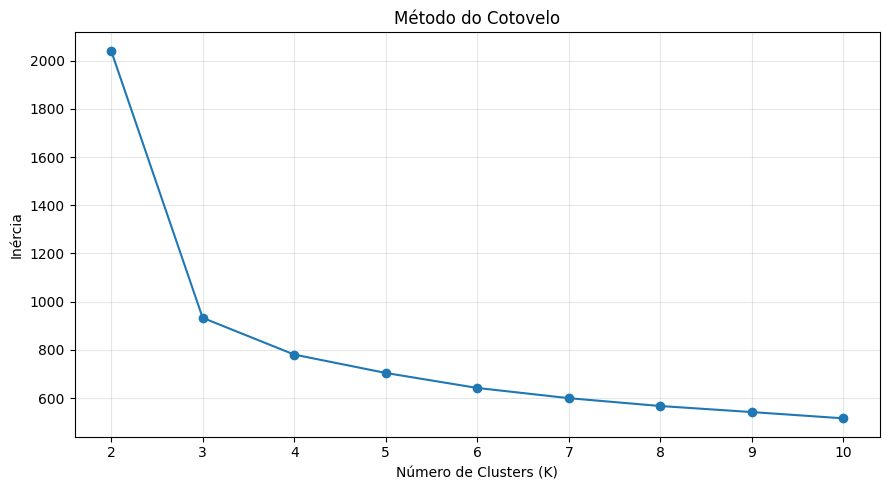

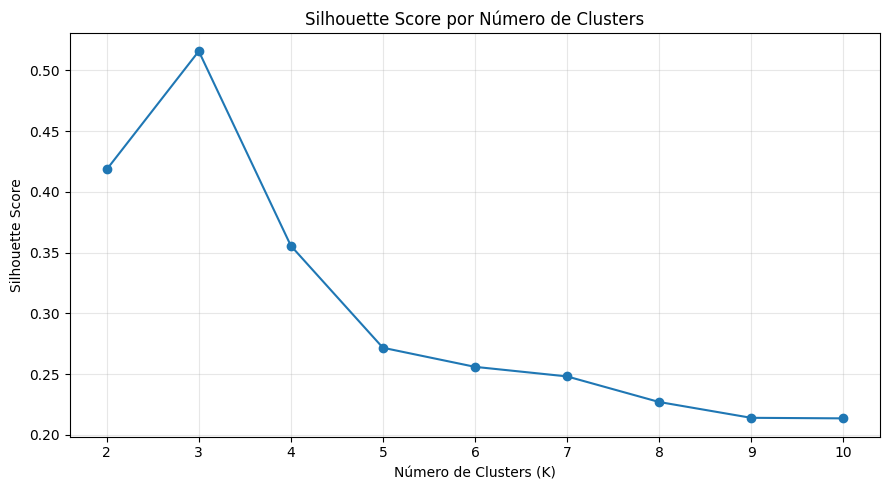


7.2 MELHOR RESULTADO PELO SILHOUETTE
Melhor K: 3
Silhouette Score: 0.5157


In [8]:
#DEFINIÇÃO DO NÚMERO DE CLUSTERS
#CONFIGURAÇÃO DOS VALORES DE K

k_values = range(2, 11)

inertias = []
silhouette_scores = []

#TREINAMENTO DOS MODELOS
print("=" * 80)
print("1. AVALIAÇÃO DOS VALORES DE K")
print("=" * 80)

for k in k_values:

    # Criar modelo
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Treinar
    labels = kmeans.fit_predict(X_scaled)

    # Inércia
    inertias.append(kmeans.inertia_)

    # Silhouette Score
    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(silhouette)

    print(
        f"K = {k:2d} | "
        f"Inércia = {kmeans.inertia_:,.2f} | "
        f"Silhouette = {silhouette:.4f}"
    )


#TABELA COMPARATIVA
print("\n" + "=" * 80)
print("2. RESULTADOS COMPARATIVOS")
print("=" * 80)

results_k = pd.DataFrame({
    "K": list(k_values),
    "Inércia": inertias,
    "Silhouette Score": silhouette_scores
})

display(
    results_k.style.format({
        "Inércia": "{:,.2f}",
        "Silhouette Score": "{:.4f}"
    })
)


#MÉTODO DO COTOVELO
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inércia")

plt.xticks(list(k_values))

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


#SILHOUETTE SCORE
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score por Número de Clusters")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(list(k_values))

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

#MELHOR K PELO SILHOUETTE
best_k_silhouette = results_k.loc[
    results_k["Silhouette Score"].idxmax(),
    "K"
]

best_silhouette = results_k["Silhouette Score"].max()

print("\n" + "=" * 80)
print("3. MELHOR RESULTADO PELO SILHOUETTE")
print("=" * 80)

print(f"Melhor K: {int(best_k_silhouette)}")
print(f"Silhouette Score: {best_silhouette:.4f}")



# Avaliação do Número de Clusters

Nesta etapa foram avaliados valores de **K entre 2 e 10** para identificar a quantidade mais adequada de clusters para o K-Means.

Foram utilizados dois critérios principais:

- **Inércia:** mede a distância dos clientes em relação ao centro de seus respectivos clusters. Quanto menor, melhor.
- **Silhouette Score:** avalia simultaneamente a coesão dos clusters e a separação entre eles. Quanto maior, melhor.

## Resultado

O melhor resultado pelo **Silhouette Score** foi obtido com:

- **K = 3**
- **Silhouette Score = 0,5157**
- **Inércia = 933,04**

O valor de K = 3 apresentou o maior Silhouette Score entre todas as configurações avaliadas.

## Decisão

Foi definido **K = 3**, pois essa configuração apresentou a melhor combinação de separação e coesão dos grupos, segundo o Silhouette Score.

A escolha de K = 3 indica que os dados apresentam **três grupos de clientes com características comportamentais relativamente distintas**.

A inércia continua diminuindo à medida que o número de clusters aumenta, o que é esperado no K-Means. Por isso, ela não deve ser analisada isoladamente. O Silhouette Score foi utilizado como principal critério de decisão, em conjunto com a análise do método do cotovelo.



In [10]:
#DEFINIÇÃO DO K
K = 3
#CRIAÇÃO DO MODELO
kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

#TREINAMENTO
cluster_labels = kmeans.fit_predict(X_scaled)

#CRIAÇÃO DA BASE COM OS CLUSTERS
df_clustered = df_model.copy()

df_clustered["Cluster"] = cluster_labels

#VERIFICAÇÃO DOS RESULTADOS
print("\n" + "=" * 80)
print("1. RESULTADO DO CLUSTERING")
print("=" * 80)

print(f"Registros analisados: {len(df_clustered):,}")
print(f"Número de clusters: {df_clustered['Cluster'].nunique()}")

#QUANTIDADE DE CLIENTES POR CLUSTER
print("\n" + "=" * 80)
print("2. TAMANHO DOS CLUSTERS")
print("=" * 80)

cluster_counts = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_summary = pd.DataFrame({
    "Quantidade de Clientes": cluster_counts,
    "Percentual da Base (%)":
        cluster_counts / len(df_clustered) * 100
})

display(
    cluster_summary.style.format({
        "Percentual da Base (%)": "{:.2f}%"
    })
)

#AMOSTRA DOS CLIENTES CLASSIFICADOS
print("\n" + "=" * 80)
print("3. AMOSTRA DOS CLIENTES CLASSIFICADOS")
print("=" * 80)

display(
    df_clustered[
        [
            "Customer Key",
            "Avg_Credit_Limit",
            "Total_Credit_Cards",
            "Total_visits_bank",
            "Total_visits_online",
            "Total_calls_made",
            "Cluster"
        ]
    ].head(20)
)


#CENTROIDES DOS CLUSTERS
centroids_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features
)

centroids_scaled.index.name = "Cluster"

print("\n" + "=" * 80)
print("4. CENTROIDES PADRONIZADOS")
print("=" * 80)

display(
    centroids_scaled.style.format("{:.3f}")
)


#AVALIAÇÃO DO MODELO
from sklearn.metrics import silhouette_score

silhouette_final = silhouette_score(
    X_scaled,
    cluster_labels
)

print("\n" + "=" * 80)
print("5. AVALIAÇÃO DO MODELO")
print("=" * 80)

print(f"Silhouette Score final: {silhouette_final:.4f}")
print(f"Inércia final: {kmeans.inertia_:,.2f}")




1. RESULTADO DO CLUSTERING
Registros analisados: 660
Número de clusters: 3

2. TAMANHO DOS CLUSTERS


,Quantidade de Clientes,Percentual da Base (%)
Cluster,,
0,386,58.48%
1,50,7.58%
2,224,33.94%



3. AMOSTRA DOS CLIENTES CLASSIFICADOS


,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Cluster
0,87073,100000,2,1,1,0,0
1,38414,50000,3,0,10,9,2
2,17341,50000,7,1,3,4,0
3,40496,30000,5,1,1,4,0
4,47437,100000,6,0,12,3,1
5,58634,20000,3,0,1,8,2
6,48370,100000,5,0,11,2,1
7,37376,15000,3,0,1,1,2
8,82490,5000,2,0,2,2,2
9,44770,3000,4,0,1,7,2



4. CENTROIDES PADRONIZADOS


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,-0.021,0.374,0.666,-0.554,-0.553
1,2.832,1.862,-1.106,2.827,-0.874
2,-0.596,-1.060,-0.902,0.323,1.148



5. AVALIAÇÃO DO MODELO
Silhouette Score final: 0.5157
Inércia final: 933.04


# Execução do K-Means
Com o modelo executado, cada cliente foi atribuído ao cluster que apresentou maior similaridade com suas características comportamentais.

## Resultado do Clustering

A distribuição dos clientes ficou da seguinte forma:

- **Cluster 0:** 386 clientes (58,48%)
- **Cluster 1:** 50 clientes (7,58%)
- **Cluster 2:** 224 clientes (33,94%)

Os centroides padronizados mostram que os três grupos apresentam padrões de comportamento diferentes, principalmente em relação ao **limite de crédito, quantidade de cartões e preferência pelos canais de atendimento**.

## Avaliação do Modelo

- **Silhouette Score:** 0,5157
- **Inércia:** 933,04
- **Número de clusters:** 3

O Silhouette Score de **0,5157** indica uma separação razoável entre os grupos, sugerindo que os clientes dentro de cada cluster possuem características semelhantes e que os clusters apresentam diferenças relevantes entre si.




9.2 MÉDIA DAS VARIÁVEIS POR CLUSTER


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,"33,782.38",5.52,3.49,0.98,2.00
1,"141,040.00",8.74,0.60,10.90,1.08
2,"12,174.11",2.41,0.93,3.55,6.87



9.3 MEDIANA DAS VARIÁVEIS POR CLUSTER


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,"31,000.00",6.00,3.00,1.00,2.00
1,"145,500.00",9.00,1.00,11.00,1.00
2,"12,000.00",2.00,1.00,4.00,7.00



9.4 LIMITES DAS VARIÁVEIS POR CLUSTER
MÍNIMOS


...


9.5 COMPARAÇÃO COM A MÉDIA GERAL
Diferença percentual em relação à média geral:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,-2.29%,+17.20%,+45.22%,-62.32%,-44.19%
1,+307.93%,+85.72%,-75.03%,+318.26%,-69.86%
2,-64.79%,-48.77%,-61.17%,+36.36%,+91.74%



9.6 PERFIL PADRONIZADO DOS CLUSTERS


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,-0.02,+0.37,+0.67,-0.55,-0.55
1,+2.83,+1.86,-1.11,+2.83,-0.87
2,-0.60,-1.06,-0.90,+0.32,+1.15



9.7 CARACTERÍSTICAS DOMINANTES

Cluster 0

Características mais elevadas:
  + Total_visits_bank: 0.67
  + Total_Credit_Cards: 0.37

Características mais baixas:
  - Total_visits_online: -0.55
  - Total_calls_made: -0.55

Cluster 1

Características mais elevadas:
  + Avg_Credit_Limit: 2.83
  + Total_visits_online: 2.83

Características mais baixas:
  - Total_visits_bank: -1.11
  - Total_calls_made: -0.87

Cluster 2

Características mais elevadas:
  + Total_calls_made: 1.15
  + Total_visits_online: 0.32

Características mais baixas:
  - Total_Credit_Cards: -1.06
  - Total_visits_bank: -0.90

9.8 MAPA DE PERFIL DOS CLUSTERS


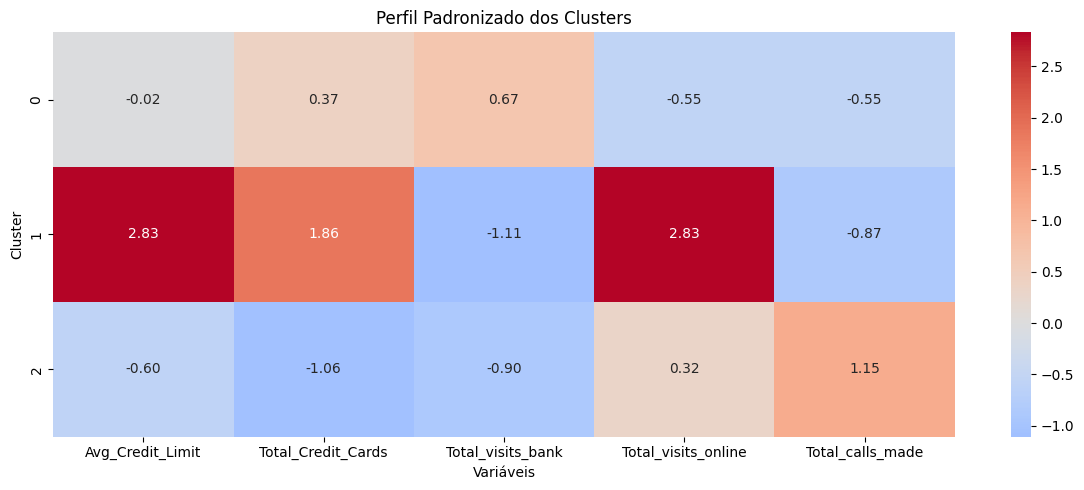

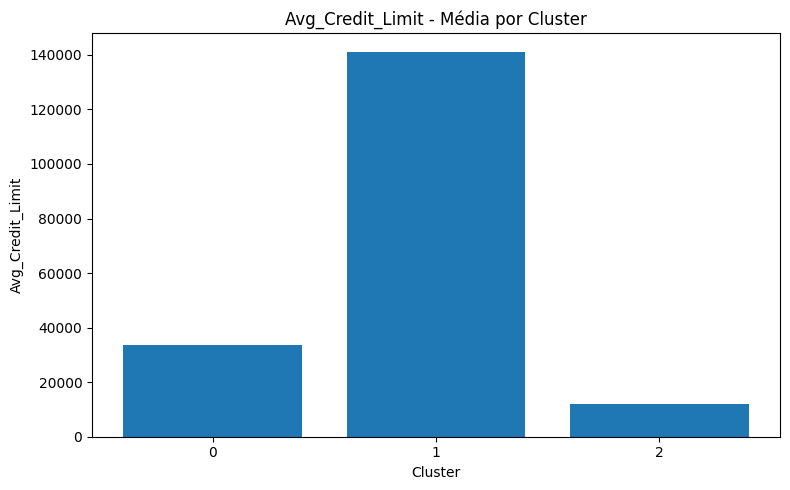

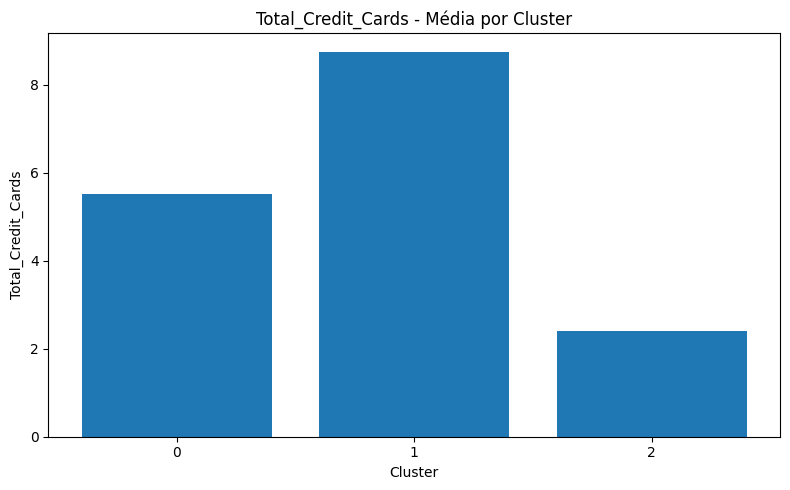

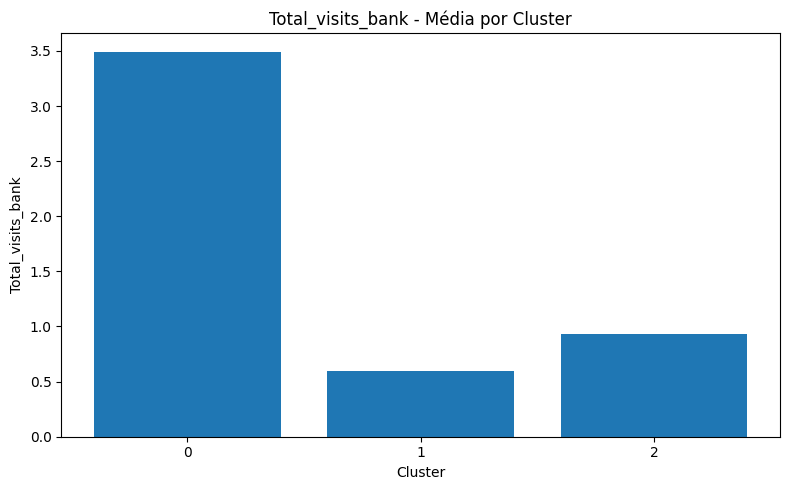

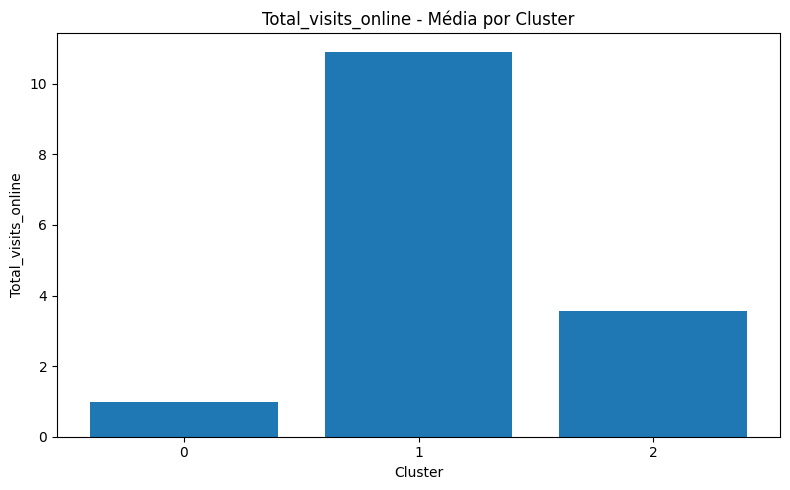

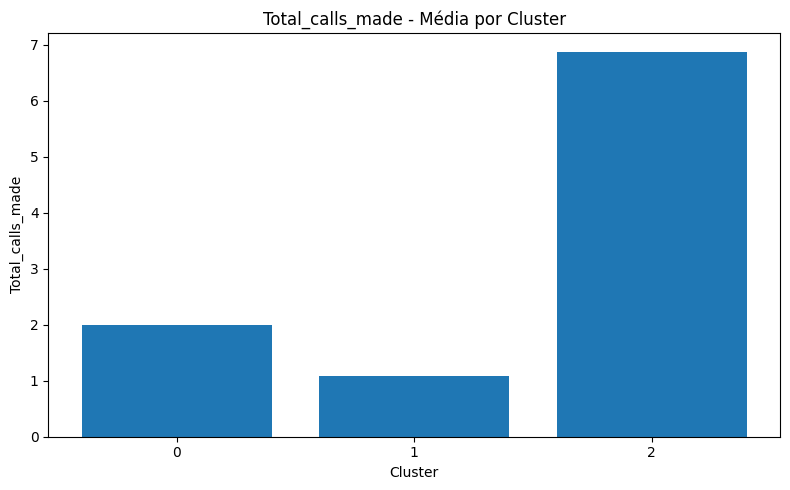


9.9 DISTRIBUIÇÃO DOS CLIENTES


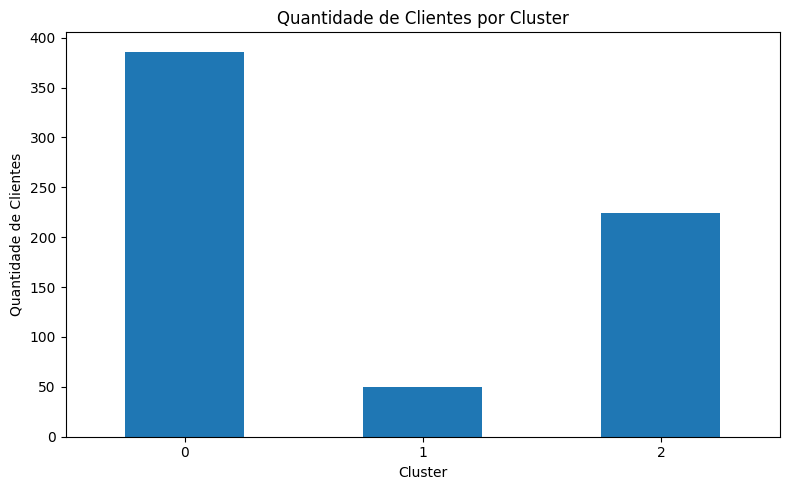


9.10 TABELA EXECUTIVA DOS CLUSTERS


,Clientes,% Base,Limite Médio,Limite Mediano,Cartões Médios,Visitas Banco,Visitas Online,Ligações
Cluster,,,,,,,,
0,386,58.48%,"33,782.38","31,000.00",5.52,3.49,0.98,2.00
1,50,7.58%,"141,040.00","145,500.00",8.74,0.60,10.90,1.08
2,224,33.94%,"12,174.11","12,000.00",2.41,0.93,3.55,6.87


In [14]:
#VERIFICAÇÃO DA BASE
cluster_size = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

#MÉDIA DAS VARIÁVEIS POR CLUSTER
print("\n" + "=" * 80)
print("1. MÉDIA DAS VARIÁVEIS POR CLUSTER")
print("=" * 80)

cluster_mean = (
    df_clustered
    .groupby("Cluster")[features]
    .mean()
)

display(
    cluster_mean.style.format("{:,.2f}")
)


#MEDIANA DAS VARIÁVEIS POR CLUSTER
print("\n" + "=" * 80)
print("2. MEDIANA DAS VARIÁVEIS POR CLUSTER")
print("=" * 80)

cluster_median = (
    df_clustered
    .groupby("Cluster")[features]
    .median()
)

display(
    cluster_median.style.format("{:,.2f}")
)

#MÍNIMO E MÁXIMO POR CLUSTER
print("\n" + "=" * 80)
print("3. LIMITES DAS VARIÁVEIS POR CLUSTER")
print("=" * 80)

cluster_min = (
    df_clustered
    .groupby("Cluster")[features]
    .min()
)

cluster_max = (
    df_clustered
    .groupby("Cluster")[features]
    .max()
)

print("MÍNIMOS")
display(
    cluster_min.style.format("{:,.2f}")
)

print("\nMÁXIMOS")
display(
    cluster_max.style.format("{:,.2f}")
)


#COMPARAÇÃO COM A MÉDIA GERAL
print("\n" + "=" * 80)
print("4. COMPARAÇÃO COM A MÉDIA GERAL")
print("=" * 80)

overall_mean = df_clustered[features].mean()

cluster_vs_overall = (
    cluster_mean
    .subtract(overall_mean)
    .divide(overall_mean)
    * 100
)

print("Diferença percentual em relação à média geral:")

display(
    cluster_vs_overall.style.format("{:+.2f}%")
)

#PERFIL PADRONIZADO DOS CLUSTERS
print("\n" + "=" * 80)
print("5. PERFIL PADRONIZADO DOS CLUSTERS")
print("=" * 80)

display(
    centroids_scaled.style.format("{:+.2f}")
)

#IDENTIFICAÇÃO DOS MAIORES E MENORES VALORES
print("\n" + "=" * 80)
print("6. CARACTERÍSTICAS DOMINANTES")
print("=" * 80)

for cluster in centroids_scaled.index:

    print(f"\nCluster {cluster}")

    cluster_values = centroids_scaled.loc[cluster]

    maiores = cluster_values.sort_values(
        ascending=False
    ).head(2)

    menores = cluster_values.sort_values(
        ascending=True
    ).head(2)

    print("\nCaracterísticas mais elevadas:")

    for feature, value in maiores.items():
        print(f"  + {feature}: {value:.2f}")

    print("\nCaracterísticas mais baixas:")

    for feature, value in menores.items():
        print(f"  - {feature}: {value:.2f}")


#HEATMAP DOS CENTROIDES
print("\n" + "=" * 80)
print("7. MAPA DE PERFIL DOS CLUSTERS")
print("=" * 80)

plt.figure(figsize=(12, 5))

sns.heatmap(
    centroids_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Perfil Padronizado dos Clusters")
plt.xlabel("Variáveis")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

#COMPARAÇÃO DAS MÉDIAS
for feature in features:

    plt.figure(figsize=(8, 5))

    values = cluster_mean[feature]

    plt.bar(
        values.index.astype(str),
        values.values
    )

    plt.title(
        f"{feature} - Média por Cluster"
    )

    plt.xlabel("Cluster")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()


#DISTRIBUIÇÃO DOS CLIENTES POR CLUSTER
print("\n" + "=" * 80)
print("8. DISTRIBUIÇÃO DOS CLIENTES")
print("=" * 80)

plt.figure(figsize=(8, 5))

cluster_size.plot(
    kind="bar"
)

plt.title("Quantidade de Clientes por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de Clientes")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#TABELA EXECUTIVA
print("\n" + "=" * 80)
print("9. TABELA EXECUTIVA DOS CLUSTERS")
print("=" * 80)

executive_profile = pd.DataFrame(index=cluster_mean.index)

executive_profile["Clientes"] = cluster_size

executive_profile["% Base"] = (
    cluster_size / len(df_clustered) * 100
)

executive_profile["Limite Médio"] = (
    cluster_mean["Avg_Credit_Limit"]
)

executive_profile["Limite Mediano"] = (
    cluster_median["Avg_Credit_Limit"]
)

executive_profile["Cartões Médios"] = (
    cluster_mean["Total_Credit_Cards"]
)

executive_profile["Visitas Banco"] = (
    cluster_mean["Total_visits_bank"]
)

executive_profile["Visitas Online"] = (
    cluster_mean["Total_visits_online"]
)

executive_profile["Ligações"] = (
    cluster_mean["Total_calls_made"]
)

display(
    executive_profile.style.format({
        "% Base": "{:.2f}%",
        "Limite Médio": "{:,.2f}",
        "Limite Mediano": "{:,.2f}",
        "Cartões Médios": "{:.2f}",
        "Visitas Banco": "{:.2f}",
        "Visitas Online": "{:.2f}",
        "Ligações": "{:.2f}"
    })
)


# Conclusão da Análise dos Clusters

A análise dos clusters permitiu transformar os grupos gerados pelo K-Means em **perfis comportamentais distintos**.

## Cluster 0

Representa o maior grupo da base, com **386 clientes (58,48%)**.

Apresenta limite de crédito intermediário, maior quantidade de cartões e forte utilização do banco físico. A utilização do canal online e a quantidade de ligações são inferiores à média geral.

**Perfil:** clientes com relacionamento mais concentrado no **atendimento presencial**, com quantidade relativamente alta de cartões.

## Cluster 1

É o menor grupo, com **50 clientes (7,58%)**, mas apresenta características bastante específicas.

Possui o maior limite de crédito médio (**141.040**) e a maior quantidade média de cartões (**8,74**). Também apresenta forte utilização do canal online (**10,90 visitas**) e baixa utilização do banco físico e do telefone.

**Perfil:** clientes de **alto valor e forte relacionamento digital**.

## Cluster 2

Possui **224 clientes (33,94%)** e apresenta o menor limite de crédito médio (**12.174**) e a menor quantidade de cartões (**2,41**).

Ao mesmo tempo, concentra a maior quantidade média de ligações (**6,87**) e apresenta maior utilização do telefone em relação aos demais grupos.

**Perfil:** clientes de **menor relacionamento financeiro**, com maior dependência do atendimento telefônico.

## Insight principal

Os resultados mostram uma segmentação clara baseada principalmente em três dimensões:

- **Valor financeiro:** representado pelo limite de crédito e quantidade de cartões;
- **Preferência de canal:** banco físico, online ou telefone;
- **Intensidade do relacionamento:** quantidade de produtos e interações com a instituição.

A segmentação permite sair de uma análise individual de 660 clientes para uma visão de **três grupos com comportamentos distintos**, facilitando a identificação de estratégias específicas para cada perfil.

A partir desses resultados, os clusters podem ser utilizados como base para **ações comerciais, relacionamento, atendimento e personalização de ofertas**, desde que essas hipóteses sejam posteriormente validadas com dados de negócio.


Variância explicada por componente:
PC1: 45.74%
PC2: 37.43%
Variância acumulada: 83.16%

Amostra dos dados após PCA:


,PC1,PC2,Cluster
0,0.50,0.52,0
1,-1.46,3.11,2
2,0.53,0.82,0
3,-0.36,0.13,0
4,1.27,3.67,1


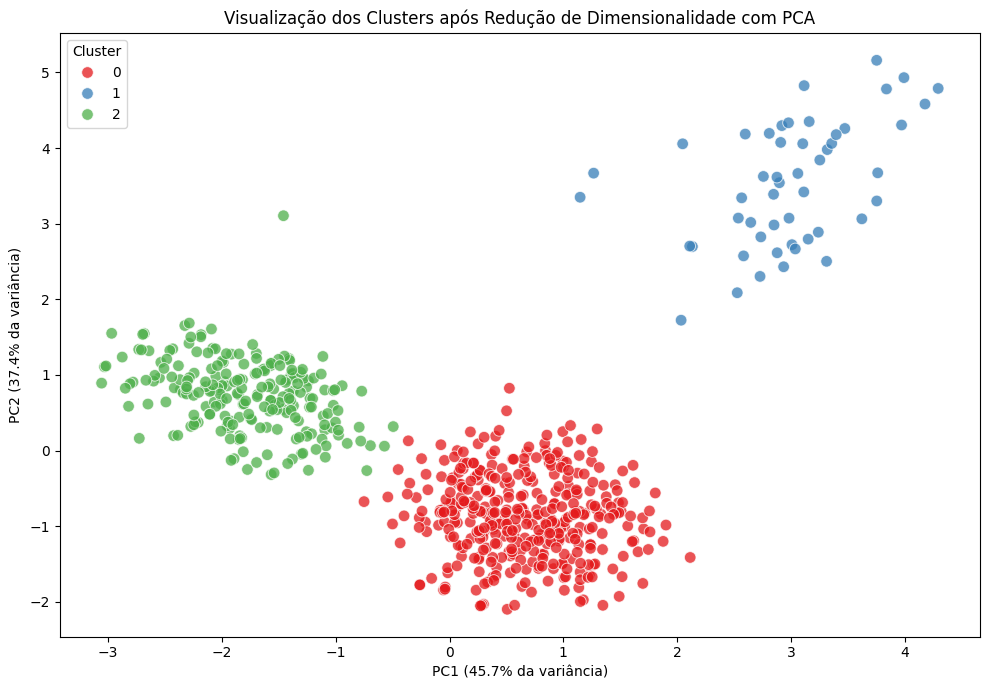

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


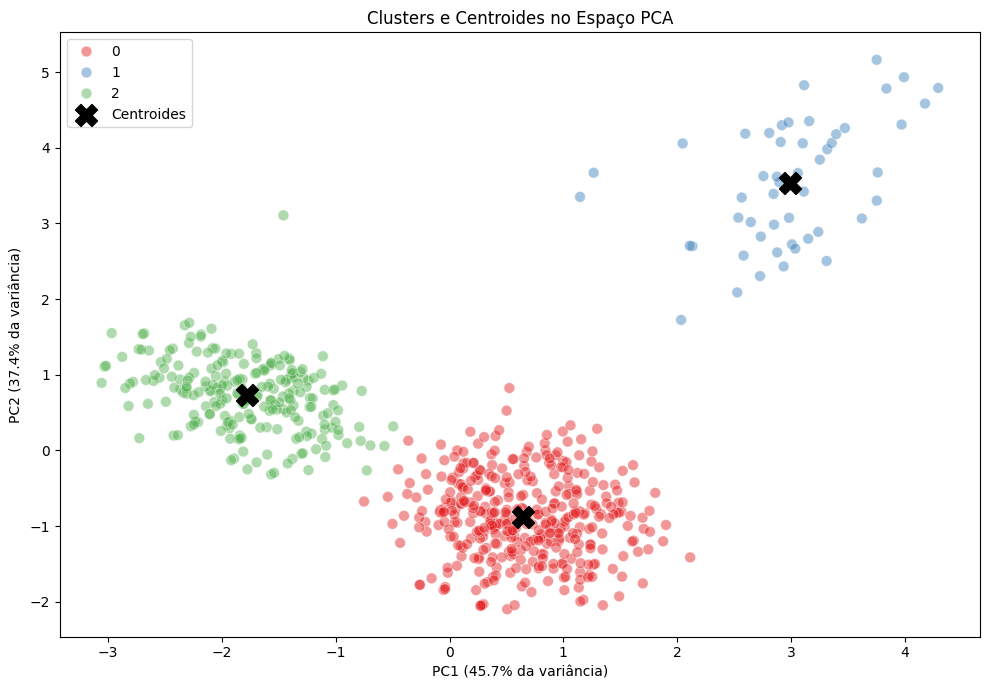

In [18]:
#VALIDAÇÃO VISUAL DOS CLUSTERS
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#VARIÂNCIA EXPLICADA
explained_variance = pca.explained_variance_ratio_

print("\nVariância explicada por componente:")

print(
    f"PC1: {explained_variance[0] * 100:.2f}%"
)

print(
    f"PC2: {explained_variance[1] * 100:.2f}%"
)

print(
    f"Variância acumulada: "
    f"{explained_variance.sum() * 100:.2f}%"
)


#CRIA DATAFRAME PARA VISUALIZAÇÃO
df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

#Adiciona os clusters encontrados pelo K-Means

df_pca["Cluster"] = df_clustered["Cluster"].values

print("\nAmostra dos dados após PCA:")

display(df_pca.head())


#GRÁFICO DOS CLUSTERS
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=70,
    alpha=0.75
)

plt.title(
    "Visualização dos Clusters após Redução de Dimensionalidade com PCA"
)

plt.xlabel(
    f"PC1 ({explained_variance[0] * 100:.1f}% da variância)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1] * 100:.1f}% da variância)"
)

plt.legend(
    title="Cluster"
)

plt.tight_layout()

plt.show()


#CENTROS DOS CLUSTERS NO ESPAÇO PCA
centroids_pca = pca.transform(
    kmeans.cluster_centers_
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=60,
    alpha=0.45
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250,
    c="black",
    label="Centroides"
)

plt.title(
    "Clusters e Centroides no Espaço PCA"
)

plt.xlabel(
    f"PC1 ({explained_variance[0] * 100:.1f}% da variância)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1] * 100:.1f}% da variância)"
)

plt.legend()

plt.tight_layout()

plt.show()


In [27]:
#MATRIZ PARA O MODELO
X = df_model[features].copy()

#PIPELINE FINAL
RANDOM_STATE = 42
pipeline_kmeans = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "kmeans",
        KMeans(
            n_clusters=K,
            random_state=RANDOM_STATE,
            n_init=10
        )
    )
])


#TREINAMENTO FINAL
pipeline_kmeans.fit(X)

#SEGMENTAÇÃO DA BASE
clusters = pipeline_kmeans.predict(X)

df_modelo = df_model.copy()

df_modelo["Cluster"] = clusters

#IDENTIFICAÇÃO DOS PERFIS
perfis = {
    0: "Relacionamento Presencial",
    1: "Relacionamento Digital",
    2: "Relacionamento Assistido"
}

df_modelo["Perfil"] = (
    df_modelo["Cluster"]
    .map(perfis)
)

#DISTRIBUIÇÃO FINAL DA SEGMENTAÇÃO
distribuicao = (
    df_modelo["Cluster"]
    .value_counts()
    .sort_index()
)

distribuicao_df = pd.DataFrame({
    "Clientes": distribuicao,
    "Percentual_Base": (
        distribuicao / len(df_modelo) * 100
    )
})


#EXEMPLO DA BASE SEGMENTADA
print("\n" + "=" * 80)
print("AMOSTRA DA BASE SEGMENTADA")
print("=" * 80)

display(
    df_modelo[
        [
            "Customer Key",
            "Cluster",
            "Perfil"
        ]
    ].head(20)
)


#SALVAMENTO DO MODELO
arquivo_modelo = "segmentacao_clientes_kmeans.pkl"

joblib.dump(
    pipeline_kmeans,
    arquivo_modelo
)


#SALVAMENTO DA BASE SEGMENTADA
arquivo_base = "clientes_segmentados.csv"

df_modelo.to_csv(
    arquivo_base,
    index=False
)


#CONFIRMAÇÃO DOS ARQUIVOS
print("\n" + "=" * 80)
print("ARTEFATOS GERADOS")
print("=" * 80)

print(f"Modelo: {arquivo_modelo}")
print(f"Base segmentada: {arquivo_base}")

print("\nModelo e base segmentada salvos com sucesso.")


AMOSTRA DA BASE SEGMENTADA


,Customer Key,Cluster,Perfil
0,87073,0,Relacionamento Presencial
1,38414,2,Relacionamento Assistido
2,17341,0,Relacionamento Presencial
3,40496,0,Relacionamento Presencial
4,47437,1,Relacionamento Digital
5,58634,2,Relacionamento Assistido
6,48370,1,Relacionamento Digital
7,37376,2,Relacionamento Assistido
8,82490,2,Relacionamento Assistido
9,44770,2,Relacionamento Assistido



ARTEFATOS GERADOS
Modelo: segmentacao_clientes_kmeans.pkl
Base segmentada: clientes_segmentados.csv

Modelo e base segmentada salvos com sucesso.


# Operacionalização e Segmentação dos Clientes

Nesta etapa, os resultados obtidos durante o desenvolvimento do modelo foram consolidados em uma aplicação reutilizável de segmentação.

Foi criado um `Pipeline` combinando o `StandardScaler` e o `KMeans`, garantindo que novos clientes sejam submetidos exatamente ao mesmo processo de transformação utilizado no treinamento.

Após o treinamento final, cada cliente recebeu um **cluster** e um **perfil comportamental**, permitindo transformar o resultado matemático do K-Means em uma segmentação mais compreensível para o negócio.

## Perfis identificados

- **Relacionamento Presencial:** clientes com maior utilização do banco físico e menor utilização dos canais digitais.
- **Relacionamento Digital:** clientes com maior limite de crédito, maior quantidade de cartões e forte utilização do canal online.
- **Relacionamento Assistido:** clientes com menor limite e quantidade de cartões, mas com maior utilização do atendimento por telefone.

Os nomes representam os **padrões comportamentais observados nos dados**, e não uma classificação de valor ou qualidade dos clientes.

## Entregas da etapa

Foram gerados dois artefatos para utilização futura:

- `segmentacao_clientes_kmeans.pkl`: modelo treinado com o processo de padronização e segmentação, permitindo classificar novos clientes.
- `clientes_segmentados.csv`: base contendo os clientes, seus respectivos clusters e perfis.



# Conclusão e Recomendações de Negócio

O projeto utilizou o algoritmo **K-Means** para identificar padrões de comportamento entre os clientes, considerando cinco características relacionadas ao relacionamento com a instituição:

- `Avg_Credit_Limit`
- `Total_Credit_Cards`
- `Total_visits_bank`
- `Total_visits_online`
- `Total_calls_made`

Após a análise exploratória, tratamento dos dados e padronização das variáveis, foram avaliadas diferentes quantidades de clusters. A configuração com **K = 3** apresentou o melhor resultado, com **Silhouette Score de 0,5157**, indicando uma separação razoável entre os grupos.

A segmentação final dos 660 registros resultou em três perfis comportamentais:

| Segmento | Clientes | % da Base | Característica principal |
|---|---:|---:|---|
| **Relacionamento Presencial** | 386 | 58,48% | Maior utilização do banco físico |
| **Relacionamento Digital** | 50 | 7,58% | Alto limite, muitos cartões e forte uso online |
| **Relacionamento Assistido** | 224 | 33,94% | Menor limite e maior utilização telefônica |

## 1. Relacionamento Presencial

Este é o maior segmento, representando **58,48% da base**.

Características médias:

- Limite de crédito: **33.782**
- Cartões: **5,52**
- Visitas ao banco: **3,49**
- Visitas online: **0,98**
- Ligações: **2,00**

O principal diferencial desse grupo é a forte utilização do canal presencial. As visitas ao banco estão aproximadamente **45% acima da média geral**, enquanto as visitas online estão cerca de **62% abaixo da média**.

### Possibilidades de atuação

Esse segmento pode ser trabalhado principalmente com estratégias de **migração e integração de canais**.

Algumas iniciativas possíveis:

- Incentivar o uso do aplicativo e internet banking para operações simples;
- Criar campanhas de educação e adoção digital;
- Oferecer benefícios para utilização dos canais digitais;
- Identificar quais serviços ainda levam o cliente à agência;
- Utilizar o atendimento presencial para oportunidades de relacionamento mais relevantes;
- Desenvolver estratégias de cross-sell durante interações presenciais.

O objetivo não deve ser simplesmente reduzir as visitas ao banco, mas entender **quais interações podem ser transferidas para canais digitais sem prejudicar a experiência**.

## 2. Relacionamento Digital

É o menor segmento, com **50 clientes (7,58%)**, mas apresenta o comportamento mais diferenciado da base.

Características médias:

- Limite de crédito: **141.040**
- Cartões: **8,74**
- Visitas ao banco: **0,60**
- Visitas online: **10,90**
- Ligações: **1,08**

Em relação à média geral, esse grupo apresenta aproximadamente:

- **308% mais limite de crédito**
- **86% mais cartões**
- **318% mais utilização online**
- **75% menos visitas ao banco**
- **70% menos ligações**

É um segmento com forte relacionamento digital e maior exposição a produtos de crédito.

### Possibilidades de atuação

Esse grupo pode receber estratégias mais personalizadas e predominantemente digitais:

- Ofertas de produtos financeiros de maior valor;
- Cross-sell e up-sell;
- Benefícios associados ao relacionamento digital;
- Campanhas personalizadas no aplicativo;
- Programas de retenção e fidelização;
- Ofertas de cartões e serviços complementares;
- Comunicação baseada no comportamento digital.

Também pode ser interessante testar estratégias de **personalização**, utilizando o comportamento digital para definir momento, canal e tipo de oferta.

É importante não classificar automaticamente esses clientes como "mais rentáveis" ou "premium", pois a base não possui informações sobre receita, saldo, rentabilidade ou inadimplência. O modelo demonstra que são clientes com **alto limite de crédito e forte relacionamento digital**.

## 3. Relacionamento Assistido

Este segmento possui **224 clientes (33,94%)**.

Características médias:

- Limite de crédito: **12.174**
- Cartões: **2,41**
- Visitas ao banco: **0,93**
- Visitas online: **3,55**
- Ligações: **6,87**

Esse grupo apresenta:

- **65% menos limite de crédito** que a média da base;
- aproximadamente **49% menos cartões**;
- **92% mais ligações**;
- baixa utilização do banco físico.

O principal diferencial é a utilização elevada do atendimento telefônico.

### Possibilidades de atuação

Esse grupo merece uma investigação mais aprofundada para entender **por que utiliza tanto o canal telefônico**.

Algumas possibilidades:

- Identificar os principais motivos das ligações;
- Avaliar se existem dificuldades de utilização dos canais digitais;
- Criar jornadas de autosserviço;
- Desenvolver comunicação educativa;
- Incentivar utilização do aplicativo;
- Identificar oportunidades de aumentar o relacionamento com produtos e serviços;
- Investigar se o elevado contato telefônico representa necessidade de suporte ou oportunidade comercial.

Uma estratégia interessante seria diferenciar clientes que utilizam o telefone por **necessidade operacional** daqueles que utilizam o canal por **preferência de relacionamento**.

## Visão Consolidada dos Segmentos

A segmentação revela três comportamentos bastante distintos:

```text
Relacionamento Presencial
58,48%
      ↓
Maior uso da agência
Menor uso online
      ↓
Oportunidade:
migração e integração de canais

Relacionamento Digital
7,58%
      ↓
Alto limite
Muitos cartões
Forte uso online
      ↓
Oportunidade:
personalização, retenção e expansão

Relacionamento Assistido
33,94%
      ↓
Menor limite
Poucos cartões
Muitas ligações
      ↓
Oportunidade:
entender necessidades, digitalização
e aumento de relacionamento